# Trading Performance Analysis with Fear & Greed Sentiment

**Author:** Soham Seal

**Email:** qwertuous@gmail.com

**GitHub:** https://github.com/sohamseal

This notebook analyzes cryptocurrency trading behavior correlated with market sentiment (Fear & Greed Index).

## 1. Data Loading

Mount Google Drive and load the historical trading data and sentiment index CSV files.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr
import warnings
import os
from dateutil import parser  # for flexible parsing

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/web3_assignment/data/"

BASE_PATH = "/content/drive/MyDrive/web3_assignment/ds_soham_seal/"
OUTPUTS_PATH = BASE_PATH + "outputs/"
CSV_PATH = BASE_PATH + "csv_files/"

# Create output directories
os.makedirs(OUTPUTS_PATH, exist_ok=True)
os.makedirs(CSV_PATH, exist_ok=True)

Mounted at /content/drive


In [3]:
# Load trading data
df_trades = pd.read_csv(DATA_PATH + 'historical_data.csv')
print(f"Trades data shape: {df_trades.shape}")
print("\nTrades columns:")
print(df_trades.columns.tolist())
print("\nFirst few rows:")
display(df_trades.head())

Trades data shape: (211224, 16)

Trades columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

First few rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
# Load sentiment data (Fear & Greed Index)
df_sentiment = pd.read_csv(DATA_PATH + 'fear_greed_index.csv')
print(f"Sentiment data shape: {df_sentiment.shape}")
print("\nSentiment columns:")
print(df_sentiment.columns.tolist())
print("\nFirst few rows:")
display(df_sentiment.head())

Sentiment data shape: (2644, 4)

Sentiment columns:
['timestamp', 'value', 'classification', 'date']

First few rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 2. Data Preprocessing

Convert timestamps, extract dates, infer leverage, and merge datasets.

In [5]:
# Convert 'Timestamp IST' to datetime and extract date

def parse_mixed_timestamp(ts_str):
    """
    Tries to parse a timestamp string with multiple formats.
    Returns datetime if successful, else NaT.
    """

    formats_to_try = [
        '%d-%m-%Y %H:%M',      # DD-MM-YYYY HH:MM (e.g., 18-03-2025 12:50)
        '%m-%d-%Y %H:%M',      # MM-DD-YYYY HH:MM (US style)
    ]

    for fmt in formats_to_try:
        try:
            return pd.to_datetime(ts_str, format=fmt)
        except ValueError:
            continue  # Try next format

In [6]:
# Parse mixed Timestamp IST
df_trades['Timestamp IST'] = df_trades['Timestamp IST'].astype(str)  # Ensure strings
df_trades['Timestamp IST'] = df_trades['Timestamp IST'].apply(parse_mixed_timestamp)
print(f"Missing timestamps: {df_trades['Timestamp IST'].isna().sum()}")
print(f"Timestamp calculated for {df_trades['Timestamp IST'].count()} trades")

df_trades['date'] = df_trades['Timestamp IST'].dt.date.astype(str)
print(f"Date range in trades: {df_trades['date'].min()} to {df_trades['date'].max()}")

Missing timestamps: 0
Timestamp calculated for 211224 trades
Date range in trades: 2023-05-01 to 2025-05-01


In [7]:
# Infer approximate leverage: Size USD / abs(Start Position)
# Only calculate where Start Position is not zero to avoid division errors
def calculate_leverage(row):
    try:
        if pd.notna(row['Start Position']) and row['Start Position'] != 0 and pd.notna(row['Size USD']):
            leverage = abs(row['Size USD']) / abs(row['Start Position'])
            # Cap extreme values (likely data issues)
            return min(leverage, 200)  # Cap at 200x for sanity
        return np.nan
    except:
        return np.nan

df_trades['approx_leverage'] = df_trades.apply(calculate_leverage, axis=1)

print(f"Leverage calculated for {df_trades['approx_leverage'].notna().sum()} trades")
print(f"Leverage statistics:\n{df_trades['approx_leverage'].describe()}")

Leverage calculated for 207139 trades
Leverage statistics:
count    207139.000000
mean         27.731922
std          64.771083
min           0.000000
25%           0.016545
50%           0.180349
75%           3.102770
max         200.000000
Name: approx_leverage, dtype: float64


In [8]:
# Ensure sentiment data has proper date format

df_sentiment['date'] = pd.to_datetime(df_sentiment['date'], errors='coerce').dt.date.astype(str)

print(f"Date range in sentiment: {df_sentiment['date'].min()} to {df_sentiment['date'].max()}")
print(f"\nSentiment classifications:")
print(df_sentiment['classification'].value_counts())

Date range in sentiment: 2018-02-01 to 2025-05-02

Sentiment classifications:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [9]:
# Merge trades with sentiment on date (left join)
df_merged = df_trades.merge(df_sentiment[['date', 'value', 'classification']],
                             on='date',
                             how='left',
                             suffixes=('', '_sentiment'))

print(f"Merged data shape: {df_merged.shape}")
print(f"Trades with sentiment data: {df_merged['classification'].notna().sum()} ({df_merged['classification'].notna().sum()/len(df_merged)*100:.1f}%)")

Merged data shape: (211224, 20)
Trades with sentiment data: 211218 (100.0%)


In [10]:
# Filter to overlapping dates only (where sentiment data exists)
df_analysis = df_merged[df_merged['classification'].notna()].copy()

print(f"Analysis dataset shape: {df_analysis.shape}")
print(f"Date range for analysis: {df_analysis['date'].min()} to {df_analysis['date'].max()}")
print(f"Unique dates: {df_analysis['date'].nunique()}")
print(f"Total dates: {df_analysis['date'].count()}")

print(f"\nSentiment breakdown:")
print(df_analysis['classification'].value_counts())

Analysis dataset shape: (211218, 20)
Date range for analysis: 2023-05-01 to 2025-05-01
Unique dates: 479
Total dates: 211218

Sentiment breakdown:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

Visualize distributions and relationships in the data.

In [11]:
df_analysis.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,approx_leverage,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,NaN,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,0.129424,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.147739,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,0.996059,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,0.054091,80.0,Extreme Greed


In [12]:
# Summary statistics
print("=== Overall Statistics ===")
print(f"Total trades: {len(df_analysis)}")
print(f"Total PnL: ${df_analysis['Closed PnL'].sum():,.2f}")
print(f"Total volume: ${df_analysis['Size USD'].sum():,.2f}")
print(f"\nClosed PnL statistics:")
print(df_analysis['Closed PnL'].describe())
print(f"\nSize USD statistics:")
print(df_analysis['Size USD'].describe())
print(f"\nApprox Leverage statistics (available trades):")
print(df_analysis['approx_leverage'].describe())

=== Overall Statistics ===
Total trades: 211218
Total PnL: $10,254,486.95
Total volume: $1,191,098,773.60

Closed PnL statistics:
count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

Size USD statistics:
count    2.112180e+05
mean     5.639192e+03
std      3.657557e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970200e+02
75%      2.058878e+03
max      3.921431e+06
Name: Size USD, dtype: float64

Approx Leverage statistics (available trades):
count    207133.000000
mean         27.732694
std          64.771862
min           0.000000
25%           0.016544
50%           0.180329
75%           3.102815
max         200.000000
Name: approx_leverage, dtype: float64


=== Trade Side by Sentiment ===


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral,All
Side,,,,,,
BUY,10935,17940,30270,24576,18969,102690
SELL,10465,22052,31567,25727,18717,108528
All,21400,39992,61837,50303,37686,211218


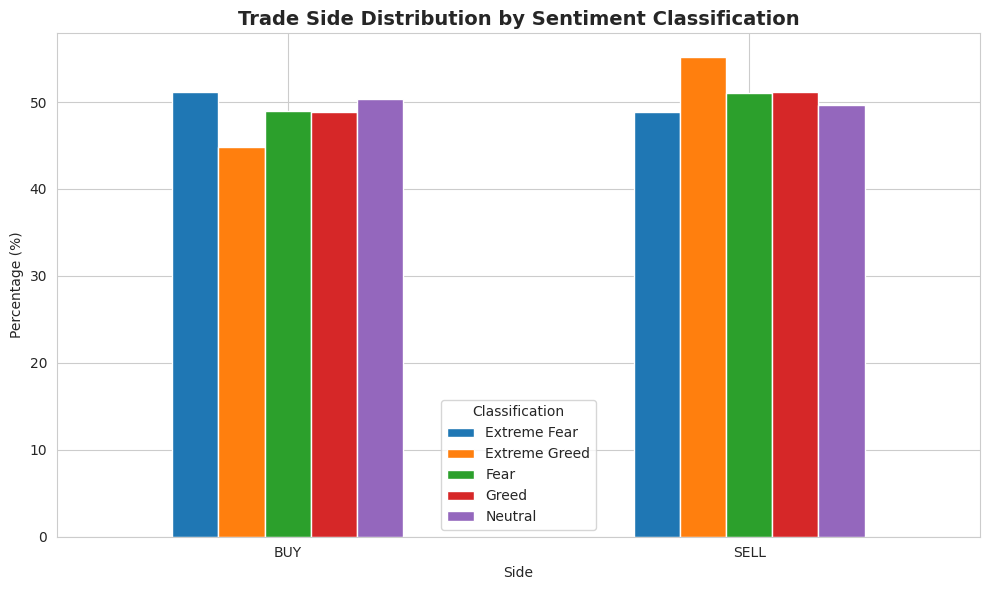

In [13]:
# Side counts by classification
print("=== Trade Side by Sentiment ===")
side_sentiment = pd.crosstab(df_analysis['Side'], df_analysis['classification'], margins=True)
display(side_sentiment)

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
side_pct = pd.crosstab(df_analysis['Side'], df_analysis['classification'], normalize='columns') * 100
side_pct.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Trade Side Distribution by Sentiment Classification', fontsize=14, fontweight='bold')
ax.set_xlabel('Side')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Classification')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'side_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

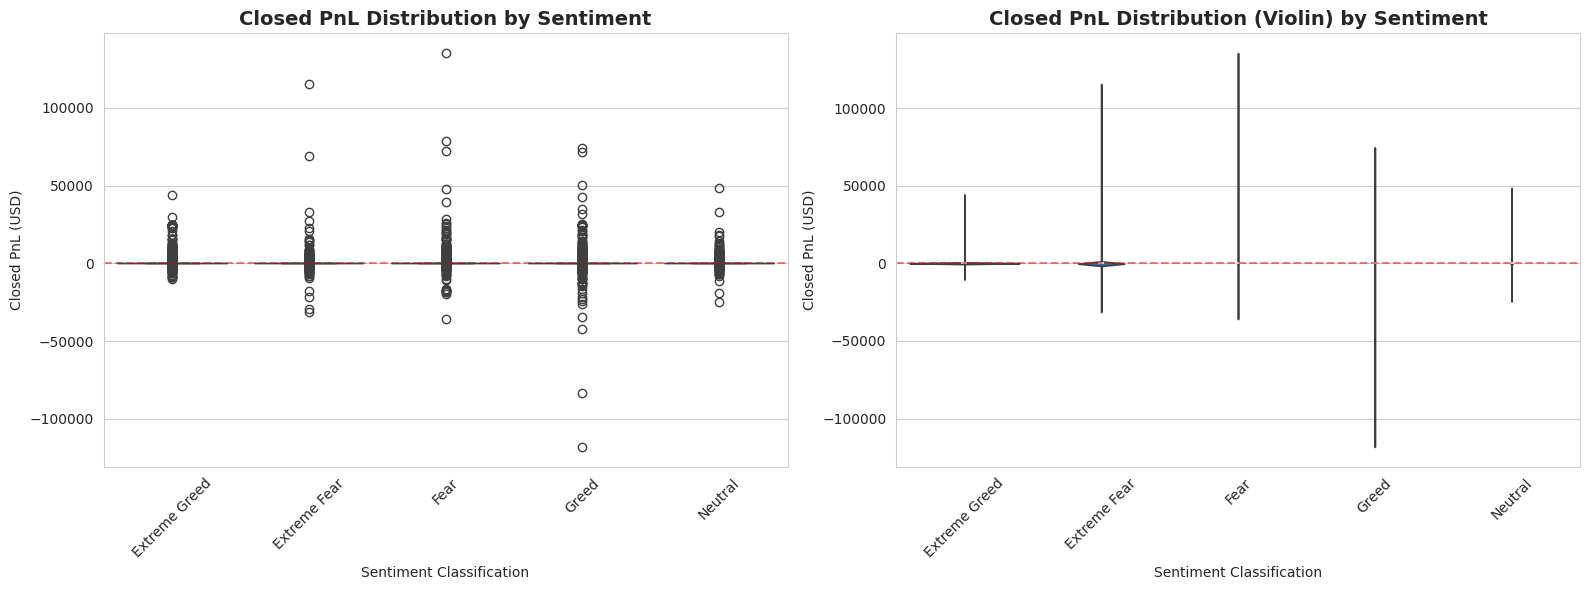

In [14]:
# Boxplot: Closed PnL by classification
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=df_analysis, x='classification', y='Closed PnL', ax=axes[0])
axes[0].set_title('Closed PnL Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Classification')
axes[0].set_ylabel('Closed PnL (USD)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# Violin plot
sns.violinplot(data=df_analysis, x='classification', y='Closed PnL', ax=axes[1])
axes[1].set_title('Closed PnL Distribution (Violin) by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment Classification')
axes[1].set_ylabel('Closed PnL (USD)')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'pnl_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

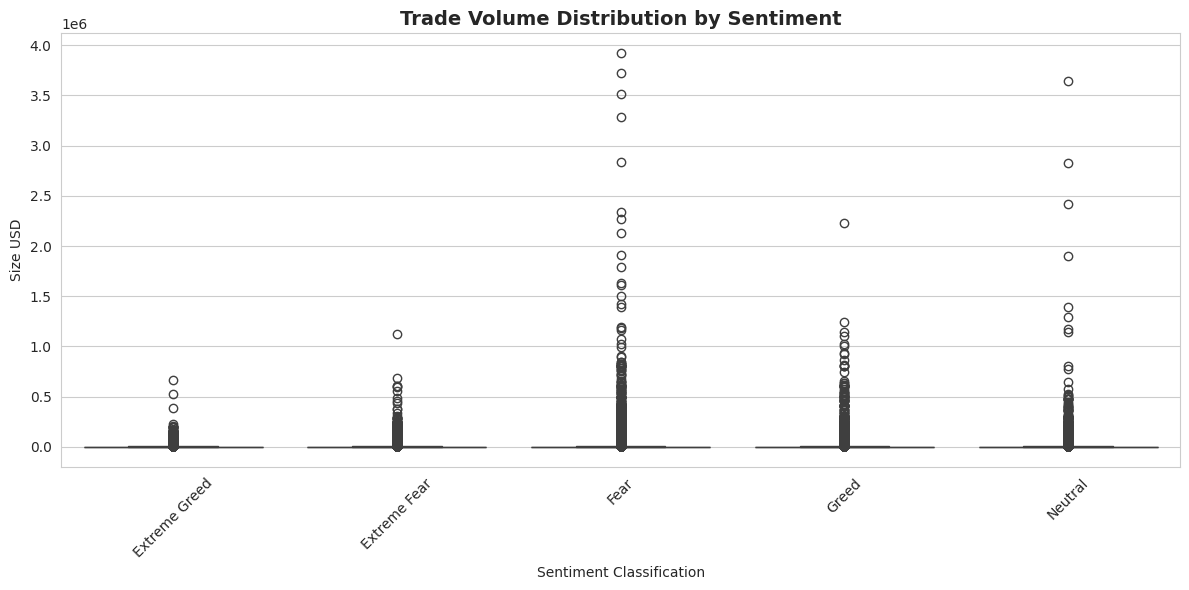

In [15]:
# Boxplot: Volume by classification
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.boxplot(data=df_analysis, x='classification', y='Size USD', ax=ax)
ax.set_title('Trade Volume Distribution by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Classification')
ax.set_ylabel('Size USD')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'volume_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

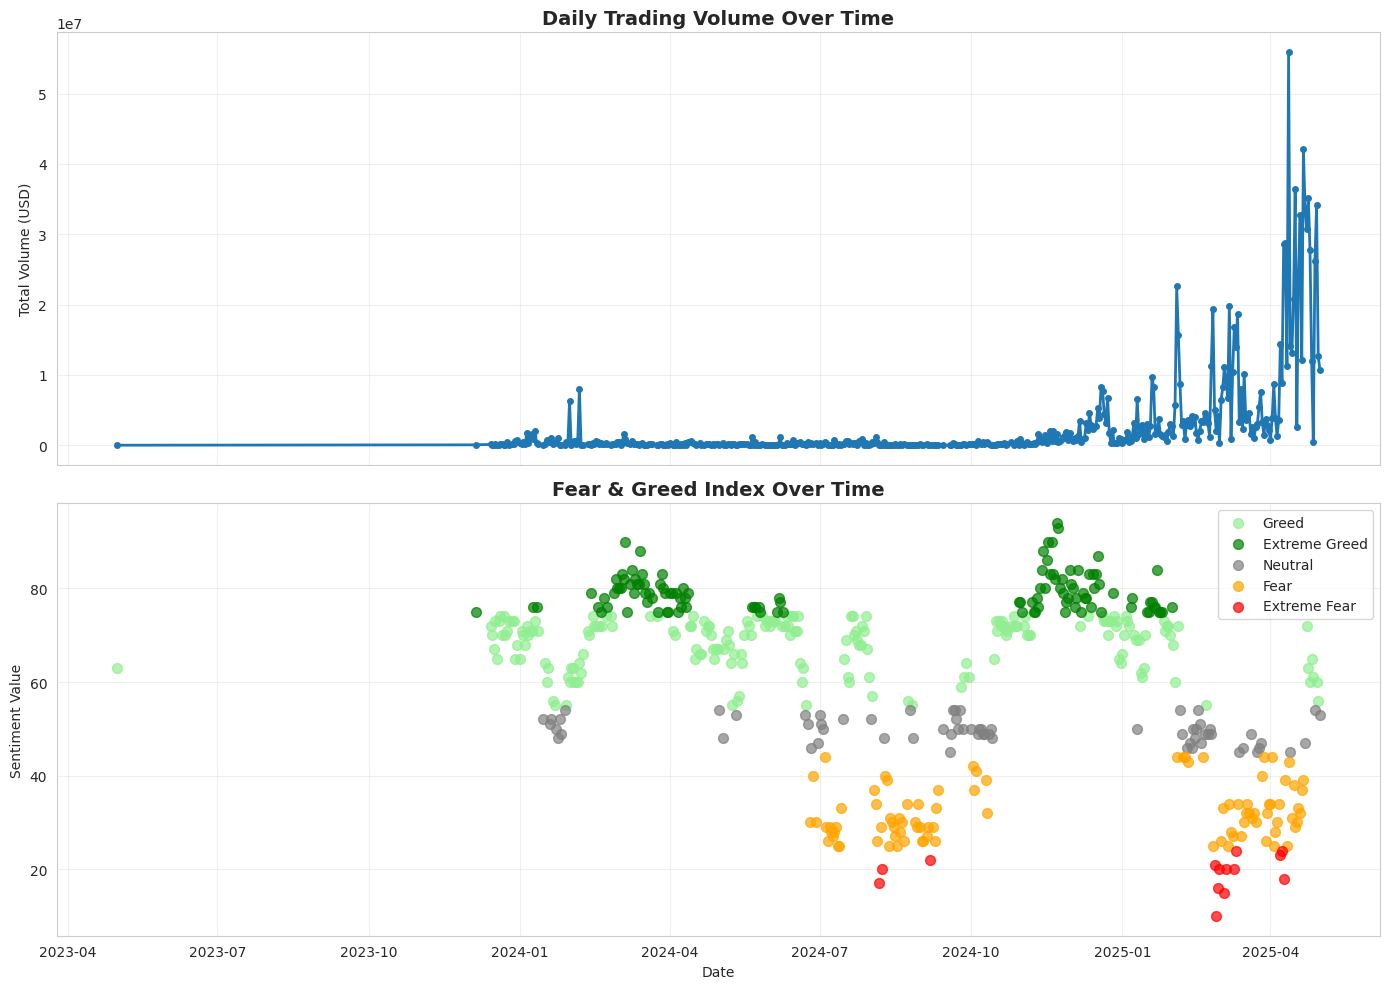

In [16]:
# Daily volume vs. sentiment value
daily_data = df_analysis.groupby('date').agg({
    'Size USD': 'sum',
    'Closed PnL': 'sum',
    'value': 'first',
    'classification': 'first'
}).reset_index()

daily_data['date_dt'] = pd.to_datetime(daily_data['date'])
daily_data = daily_data.sort_values('date_dt')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Daily volume
axes[0].plot(daily_data['date_dt'], daily_data['Size USD'], marker='o', linewidth=2, markersize=4)
axes[0].set_title('Daily Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Volume (USD)')
axes[0].grid(True, alpha=0.3)

# Fear & Greed Index
color_map = {'Extreme Fear': 'red', 'Fear': 'orange', 'Neutral': 'gray', 'Greed': 'lightgreen', 'Extreme Greed': 'green'}
for classification in daily_data['classification'].unique():
    subset = daily_data[daily_data['classification'] == classification]
    axes[1].scatter(subset['date_dt'], subset['value'],
                   label=classification,
                   c=color_map.get(classification, 'blue'),
                   s=50, alpha=0.7)

axes[1].set_title('Fear & Greed Index Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sentiment Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'daily_volume_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

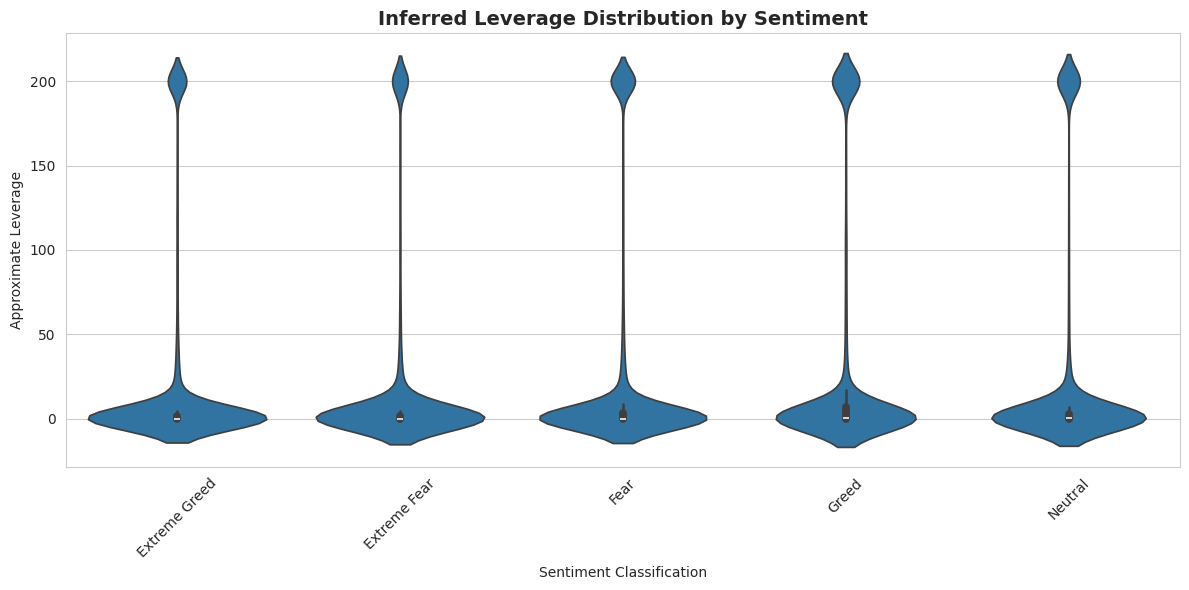

In [17]:
# Leverage distribution by sentiment (for available data)
df_with_leverage = df_analysis[df_analysis['approx_leverage'].notna()]

if len(df_with_leverage) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    sns.violinplot(data=df_with_leverage, x='classification', y='approx_leverage', ax=ax)
    ax.set_title('Inferred Leverage Distribution by Sentiment', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sentiment Classification')
    ax.set_ylabel('Approximate Leverage')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH + 'leverage_by_sentiment.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No leverage data available for visualization.")

## 4. Basic Statistical Analysis

Aggregate metrics by sentiment and calculate correlations.

In [20]:
# Group by classification: mean/median PnL, volume, leverage, buy/sell ratio
sentiment_agg = df_analysis.groupby('classification').agg({
    'Closed PnL': ['mean', 'median', 'sum', 'count'],
    'Size USD': ['sum', 'mean', 'median'],
    'approx_leverage': ['mean', 'median'],
}).round(2)

print("=== Metrics by Sentiment Classification ===")
display(sentiment_agg)

# Buy/Sell ratio
side_ratio = df_analysis.groupby('classification')['Side'].value_counts(normalize=True).unstack(fill_value=0)
if 'BUY' in side_ratio.columns and 'SELL' in side_ratio.columns:
    side_ratio['buy_sell_ratio'] = (side_ratio['BUY'] / side_ratio['SELL']).replace([np.inf, -np.inf], np.nan)
else:
    # Handle case where only one side exists
    side_ratio['buy_sell_ratio'] = np.nan

print("\n=== Buy/Sell Ratio by Sentiment ===")
display(side_ratio)

=== Metrics by Sentiment Classification ===


Closed PnL                                Size USD           \
                     mean median         sum  count           sum     mean   
classification                                                               
Extreme Fear        34.54    0.0   739110.25  21400  1.144843e+08  5349.73   
Extreme Greed       67.89    0.0  2715171.31  39992  1.244652e+08  3112.25   
Fear                54.29    0.0  3357155.44  61837  4.833248e+08  7816.11   
Greed               42.74    0.0  2150129.27  50303  2.885825e+08  5736.88   
Neutral             34.31    0.0  1292920.68  37686  1.802421e+08  4782.73   

                       approx_leverage         
                median            mean median  
classification                                 
Extreme Fear    766.15           20.06   0.15  
Extreme Greed   500.05           22.21   0.14  
Fear            735.96           27.94   0.18  
Greed           555.00           35.16   0.22  
Neutral         547.66           27.74   0.21


=== Buy/Sell Ratio by Sentiment ===


Side,BUY,SELL,buy_sell_ratio
classification,,,
Extreme Fear,0.510981,0.489019,1.044912
Extreme Greed,0.448590,0.551410,0.813532
Fear,0.489513,0.510487,0.958913
Greed,0.488559,0.511441,0.955261
Neutral,0.503343,0.496657,1.013464


=== Pearson Correlations with Sentiment Value ===
Sentiment Value vs. Closed PnL: r=0.0086, p=0.0001
Sentiment Value vs. Size USD: r=-0.0313, p=0.0000
Sentiment Value vs. Approx Leverage: r=0.0223, p=0.0000


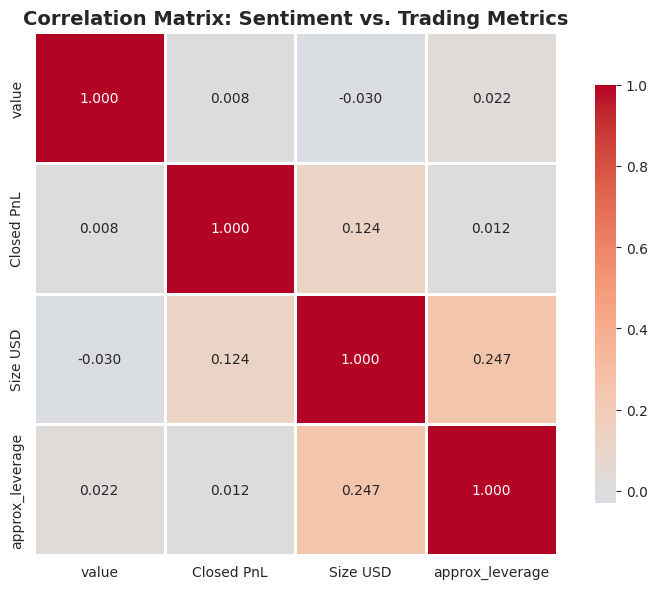

In [21]:
# Pearson correlations: sentiment value vs. PnL, volume, leverage
print("=== Pearson Correlations with Sentiment Value ===")

# Filter out missing values for correlation
corr_data = df_analysis[['value', 'Closed PnL', 'Size USD', 'approx_leverage']].dropna()

if len(corr_data) > 10:  # Need sufficient data points
    # PnL correlation
    corr_pnl, p_pnl = pearsonr(corr_data['value'], corr_data['Closed PnL'])
    print(f"Sentiment Value vs. Closed PnL: r={corr_pnl:.4f}, p={p_pnl:.4f}")

    # Volume correlation
    corr_vol, p_vol = pearsonr(corr_data['value'], corr_data['Size USD'])
    print(f"Sentiment Value vs. Size USD: r={corr_vol:.4f}, p={p_vol:.4f}")

    # Leverage correlation (if available)
    if corr_data['approx_leverage'].notna().sum() > 10:
        leverage_data = corr_data[corr_data['approx_leverage'].notna()]
        corr_lev, p_lev = pearsonr(leverage_data['value'], leverage_data['approx_leverage'])
        print(f"Sentiment Value vs. Approx Leverage: r={corr_lev:.4f}, p={p_lev:.4f}")
else:
    print("Insufficient data for correlation analysis.")

# Correlation heatmap
corr_matrix = df_analysis[['value', 'Closed PnL', 'Size USD', 'approx_leverage']].corr()
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix: Sentiment vs. Trading Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# -------------------------------------------------
# 1. DAILY AGGREGATION (fixes independence issue)
# -------------------------------------------------

# Count buys and sells per day
daily_side = (
    df_analysis
    .groupby('date')['Side']
    .value_counts()
    .unstack(fill_value=0)
)

# Ensure both Buy and Sell columns exist
daily_side = daily_side.reindex(columns=['BUY', 'SELL'], fill_value=0)

# Create dominant side for the day
daily_side['Dominant_Side'] = daily_side.apply(
    lambda row: 'BUY' if row['BUY'] > row['SELL']
    else 'SELL' if row['SELL'] > row['BUY']
    else 'Neutral',
    axis=1
)

# -------------------------------------------------
# 2. MERGE WITH FEAR–GREED CLASSIFICATION (daily)
# -------------------------------------------------

daily_sentiment = (
    df_analysis[['date', 'classification']]
    .drop_duplicates()
    .set_index('date')
)

df_daily = daily_side.join(daily_sentiment, how='inner')

# Remove neutral days (optional but recommended)
df_daily = df_daily[df_daily['Dominant_Side'] != 'Neutral']

# -------------------------------------------------
# 3. CONTINGENCY TABLE
# -------------------------------------------------

contingency_table = pd.crosstab(
    df_daily['Dominant_Side'],
    df_daily['classification']
)

print("=== Contingency Table ===")
print(contingency_table)

# -------------------------------------------------
# 4. CHI-SQUARE TEST
# -------------------------------------------------

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n=== Chi-Square Test: Daily Dominant Side vs. Sentiment ===")
print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value             : {p_value:.4f}")
print(f"Degrees of freedom  : {dof}")

# -------------------------------------------------
# 5. EXPECTED FREQUENCY CHECK (IMPORTANT)
# -------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

if (expected_df < 5).any().any():
    print("\n⚠ Warning: Some expected cell counts are < 5.")
    print("Chi-square assumptions may be violated.")
else:
    print("\nAll expected cell counts ≥ 5. Assumptions satisfied.")

# -------------------------------------------------
# 6. INTERPRETATION
# -------------------------------------------------

if p_value < 0.05:
    print("\nResult: Statistically significant association (p < 0.05)")
else:
    print("\nResult: No statistically significant association (p ≥ 0.05)")


=== Contingency Table ===
classification  Extreme Fear  Extreme Greed  Fear  Greed  Neutral
Dominant_Side                                                    
BUY                        8             46    46     86       35
SELL                       6             67    45    105       31

=== Chi-Square Test: Daily Dominant Side vs. Sentiment ===
Chi-square statistic : 4.0588
P-value             : 0.3981
Degrees of freedom  : 4

All expected cell counts ≥ 5. Assumptions satisfied.

Result: No statistically significant association (p ≥ 0.05)


## 5. Key Insights & Divergence Analysis

Quantify specific patterns and trading behaviors across sentiment regimes.

In [40]:
# Insight 1: Win-rate comparison for low-leverage trades

df_low_leverage = df_analysis[df_analysis['approx_leverage'] < 10].copy()

# Create binary outcome: profitable or not
df_low_leverage['Profitable'] = df_low_leverage['Closed PnL'] > 0

fear_trades = df_low_leverage[
    df_low_leverage['classification'].str.contains('Fear', case=False, na=False)
]

greed_trades = df_low_leverage[
    df_low_leverage['classification'].str.contains('Greed', case=False, na=False)
]

if len(fear_trades) >= 10 and len(greed_trades) >= 10:
    fear_winrate = fear_trades['Profitable'].mean() * 100
    greed_winrate = greed_trades['Profitable'].mean() * 100
    diff = fear_winrate - greed_winrate

    print("=== INSIGHT 1: Low-Leverage Trade Win Rates ===")
    print(f"Fear periods   : {fear_winrate:.1f}% profitable trades (n={len(fear_trades)})")
    print(f"Greed periods  : {greed_winrate:.1f}% profitable trades (n={len(greed_trades)})")
    print(f"Difference     : {diff:+.1f} percentage points")

    if diff > 0:
        print("Low-leverage trades perform better during Fear, supporting a contrarian bias.")
    else:
        print("No contrarian advantage observed for low-leverage trades.")
else:
    print("Insufficient low-leverage trade counts for Fear vs Greed comparison.")


=== INSIGHT 1: Low-Leverage Trade Win Rates ===
Fear periods   : 42.3% profitable trades (n=66269)
Greed periods  : 45.7% profitable trades (n=69770)
Difference     : -3.5 percentage points
No contrarian advantage observed for low-leverage trades.


In [41]:
# Insight 2: Volume and Loss Patterns
print(f"\n=== INSIGHT 2: Volume and Loss Patterns ===")
print(f"Total volume during Greed: ${greed_vol:,.2f}")
print(f"Total volume during Fear: ${fear_vol:,.2f}")
print(f"Volume ratio (Greed/Fear): {greed_vol/fear_vol:.2f}x" if fear_vol > 0 else "N/A")

print(f"\nLosing trade percentage in Greed: {greed_loss_pct:.1f}%")
print(f"Losing trade percentage in Fear: {fear_loss_pct:.1f}%")

print(f"\nTotal PnL in Greed: ${greed_pnl_total:,.2f}")
print(f"Total PnL in Fear: ${fear_pnl_total:,.2f}")

# Interpretation logic
print("\nInterpretation:")

if greed_loss_pct > fear_loss_pct:
    print(
        "Trades executed during Greed show a higher loss rate than during Fear, "
        "suggesting lower execution quality or overconfidence."
    )

if greed_vol > fear_vol:
    print(
        "Trading volume is higher during Greed, indicating increased participation "
        "and potential overtrading."
    )
else:
    print(
        "Trading volume is higher during Fear, indicating elevated activity during "
        "stressful market conditions rather than euphoric phases."
    )

if greed_loss_pct > fear_loss_pct and greed_pnl_total >= fear_pnl_total:
    print(
        "Despite higher loss rates, aggregate Greed-period PnL remains positive, "
        "suggesting gains are driven by fewer but larger winning trades."
    )



=== INSIGHT 2: Volume and Loss Patterns ===
Total volume during Greed: $413,047,659.29
Total volume during Fear: $597,809,051.23
Volume ratio (Greed/Fear): 0.69x

Losing trade percentage in Greed: 8.9%
Losing trade percentage in Fear: 7.5%

Total PnL in Greed: $4,865,300.58
Total PnL in Fear: $4,096,265.69

Interpretation:
Trades executed during Greed show a higher loss rate than during Fear, suggesting lower execution quality or overconfidence.
Trading volume is higher during Fear, indicating elevated activity during stressful market conditions rather than euphoric phases.
Despite higher loss rates, aggregate Greed-period PnL remains positive, suggesting gains are driven by fewer but larger winning trades.


=== INSIGHT 3: PnL Performance by Sentiment ===


,mean,median,sum,count
classification,,,,
Extreme Greed,67.892861,0.0,2.715171e+06,39992
Fear,54.290400,0.0,3.357155e+06,61837
Greed,42.743559,0.0,2.150129e+06,50303
Extreme Fear,34.537862,0.0,7.391102e+05,21400
Neutral,34.307718,0.0,1.292921e+06,37686


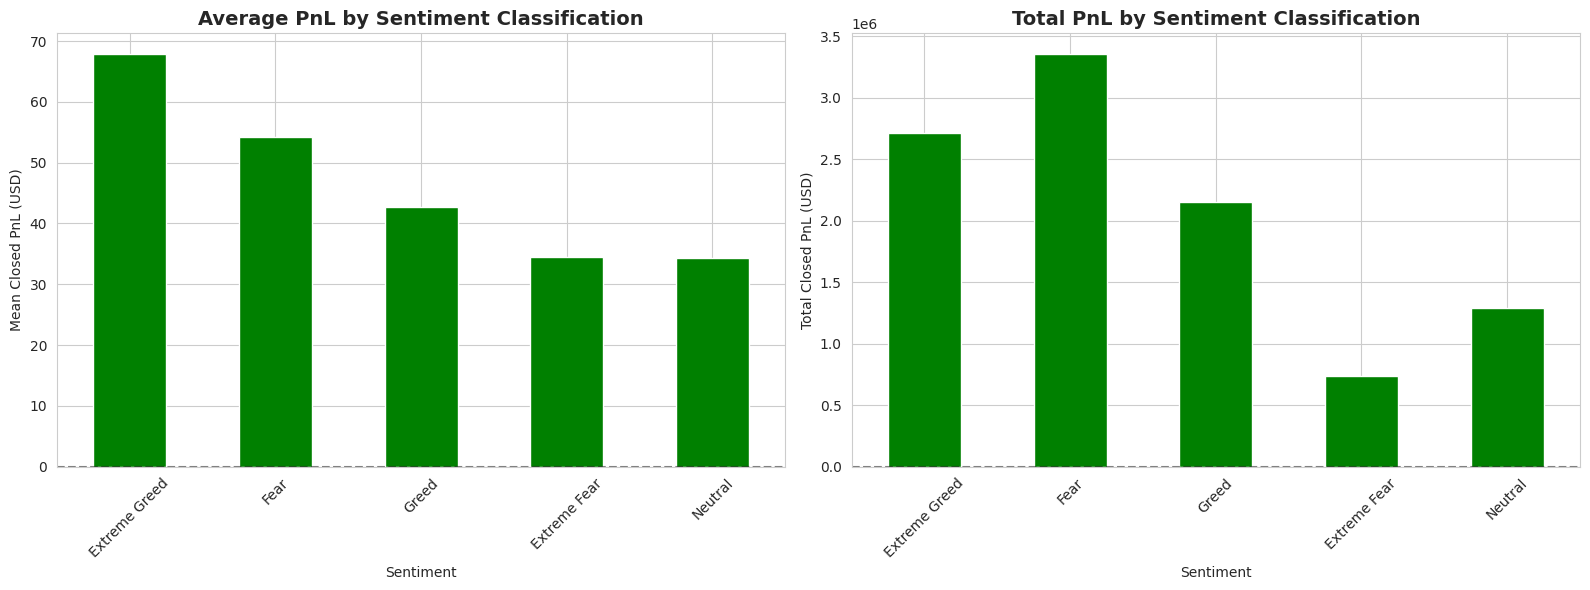

In [42]:
# Insight 3: PnL by sentiment regime
pnl_by_sentiment = df_analysis.groupby('classification')['Closed PnL'].agg(['mean', 'median', 'sum', 'count'])
pnl_by_sentiment = pnl_by_sentiment.sort_values('mean', ascending=False)

print(f"=== INSIGHT 3: PnL Performance by Sentiment ===")
display(pnl_by_sentiment)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean PnL
pnl_by_sentiment['mean'].plot(kind='bar', ax=axes[0], color=['green' if x > 0 else 'red' for x in pnl_by_sentiment['mean']])
axes[0].set_title('Average PnL by Sentiment Classification', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Mean Closed PnL (USD)')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# Total PnL
pnl_by_sentiment['sum'].plot(kind='bar', ax=axes[1], color=['green' if x > 0 else 'red' for x in pnl_by_sentiment['sum']])
axes[1].set_title('Total PnL by Sentiment Classification', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Total Closed PnL (USD)')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'pnl_comparison_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

=== INSIGHT 4: Win Rate by Sentiment ===


,Winning Trades,Total Trades,Win Rate
classification,,,
Extreme Fear,7931,21400,37.06
Extreme Greed,18594,39992,46.49
Fear,26019,61837,42.08
Greed,19358,50303,38.48
Neutral,14961,37686,39.70


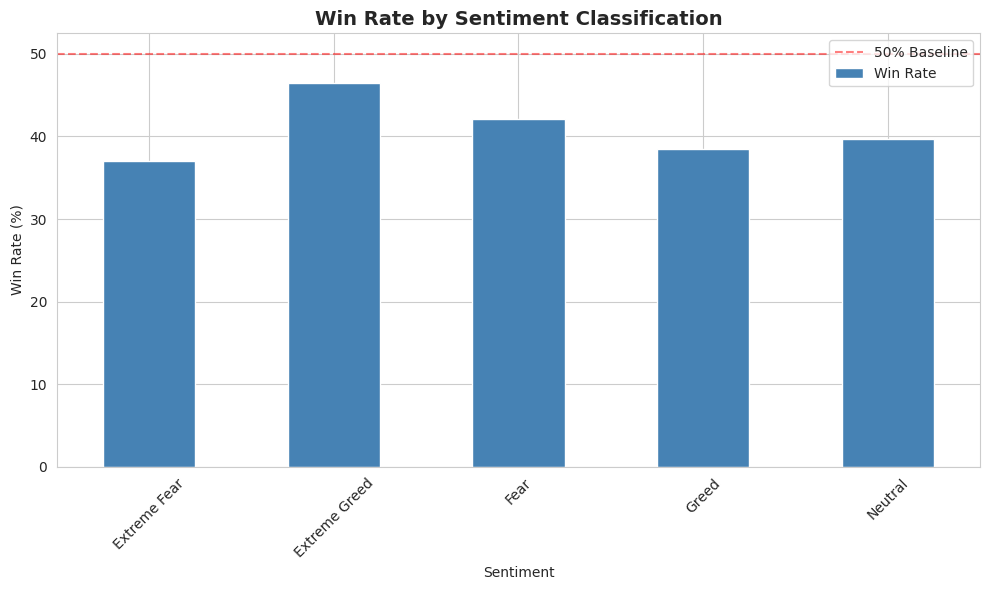

In [43]:
# Insight 4: Win rate analysis
df_analysis['is_profitable'] = df_analysis['Closed PnL'] > 0
win_rate = df_analysis.groupby('classification')['is_profitable'].agg(['sum', 'count', 'mean'])
win_rate.columns = ['Winning Trades', 'Total Trades', 'Win Rate']
win_rate['Win Rate'] = (win_rate['Win Rate'] * 100).round(2)

print(f"=== INSIGHT 4: Win Rate by Sentiment ===")
display(win_rate)

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
win_rate['Win Rate'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Win Rate by Sentiment Classification', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Win Rate (%)')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% Baseline')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'win_rate_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Insight 5: Extreme sentiment behavior
extreme_fear = df_analysis[df_analysis['classification'] == 'Extreme Fear']
extreme_greed = df_analysis[df_analysis['classification'] == 'Extreme Greed']

print(f"=== INSIGHT 5: Extreme Sentiment Analysis ===")
print(f"\nExtreme Fear:")
print(f"  Trades: {len(extreme_fear)}")
print(f"  Avg PnL: ${extreme_fear['Closed PnL'].mean():.2f}")
print(f"  Median PnL: ${extreme_fear['Closed PnL'].median():.2f}")
print(f"  Win Rate: {(extreme_fear['Closed PnL'] > 0).sum() / len(extreme_fear) * 100:.1f}%" if len(extreme_fear) > 0 else "N/A")

print(f"\nExtreme Greed:")
print(f"  Trades: {len(extreme_greed)}")
print(f"  Avg PnL: ${extreme_greed['Closed PnL'].mean():.2f}")
print(f"  Median PnL: ${extreme_greed['Closed PnL'].median():.2f}")
print(f"  Win Rate: {(extreme_greed['Closed PnL'] > 0).sum() / len(extreme_greed) * 100:.1f}%" if len(extreme_greed) > 0 else "N/A")

if len(extreme_fear) > 0 and len(extreme_greed) > 0:
    ef_median = extreme_fear['Closed PnL'].median()
    eg_median = extreme_greed['Closed PnL'].median()
    if ef_median > eg_median:
        print(f"\nContrarian signal: Extreme Fear shows better median returns (${ef_median:.2f} vs ${eg_median:.2f}).")

=== INSIGHT 5: Extreme Sentiment Analysis ===

Extreme Fear:
  Trades: 21400
  Avg PnL: $34.54
  Median PnL: $0.00
  Win Rate: 37.1%

Extreme Greed:
  Trades: 39992
  Avg PnL: $67.89
  Median PnL: $0.00
  Win Rate: 46.5%


## 6. Export Results

Save merged and aggregated data to CSV files.

In [45]:
# Export merged analysis data
output_path_merged = CSV_PATH + 'merged_data.csv'
df_analysis.to_csv(output_path_merged, index=False)
print(f"Merged data exported to: {output_path_merged}")
print(f"Shape: {df_analysis.shape}")

Merged data exported to: /content/drive/MyDrive/web3_assignment/ds_soham_seal/csv_files/merged_data.csv
Shape: (211218, 21)


In [46]:
# Export aggregated metrics by sentiment
agg_output = df_analysis.groupby('classification').agg({
    'Closed PnL': ['count', 'sum', 'mean', 'median', 'std'],
    'Size USD': ['sum', 'mean', 'median'],
    'approx_leverage': ['mean', 'median'],
    'Timestamp IST': ['min', 'max']
}).reset_index()

# Flatten column names
agg_output.columns = ['_'.join(col).strip('_') for col in agg_output.columns.values]

output_path_agg = CSV_PATH + 'sentiment_aggregated.csv'
agg_output.to_csv(output_path_agg, index=False)
print(f"\nAggregated data by sentiment exported to: {output_path_agg}")
display(agg_output)


Aggregated data by sentiment exported to: /content/drive/MyDrive/web3_assignment/ds_soham_seal/csv_files/sentiment_aggregated.csv


,classification,Closed PnL_count,Closed PnL_sum,Closed PnL_mean,Closed PnL_median,Closed PnL_std,Size USD_sum,Size USD_mean,Size USD_median,approx_leverage_mean,approx_leverage_median,Timestamp IST_min,Timestamp IST_max
0,Extreme Fear,21400,7.391102e+05,34.537862,0.0,1136.056091,1.144843e+08,5349.731843,766.150,20.057978,0.150616,2024-08-06 00:51:00,2025-04-09 23:57:00
1,Extreme Greed,39992,2.715171e+06,67.892861,0.0,766.828294,1.244652e+08,3112.251565,500.050,22.211525,0.137503,2023-12-05 03:11:00,2025-01-31 23:32:00
2,Fear,61837,3.357155e+06,54.290400,0.0,935.355438,4.833248e+08,7816.109931,735.960,27.941141,0.178899,2024-06-25 01:50:00,2025-04-21 23:24:00
3,Greed,50303,2.150129e+06,42.743559,0.0,1116.028390,2.885825e+08,5736.884375,555.000,35.163193,0.218245,2023-05-01 01:06:00,2025-04-30 23:52:00
4,Neutral,37686,1.292921e+06,34.307718,0.0,517.122220,1.802421e+08,4782.732661,547.655,27.739049,0.209670,2024-01-15 09:40:00,2025-05-01 12:13:00


In [47]:
# Export daily summary
output_path_daily = CSV_PATH + 'daily_summary.csv'
daily_data.to_csv(output_path_daily, index=False)
print(f"\nDaily summary exported to: {output_path_daily}")
print(f"Shape: {daily_data.shape}")


Daily summary exported to: /content/drive/MyDrive/web3_assignment/ds_soham_seal/csv_files/daily_summary.csv
Shape: (479, 6)


In [48]:
# Export win rate analysis
output_path_winrate = CSV_PATH + 'win_rate_by_sentiment.csv'
win_rate.to_csv(output_path_winrate)
print(f"\nWin rate analysis exported to: {output_path_winrate}")
display(win_rate)


Win rate analysis exported to: /content/drive/MyDrive/web3_assignment/ds_soham_seal/csv_files/win_rate_by_sentiment.csv


,Winning Trades,Total Trades,Win Rate
classification,,,
Extreme Fear,7931,21400,37.06
Extreme Greed,18594,39992,46.49
Fear,26019,61837,42.08
Greed,19358,50303,38.48
Neutral,14961,37686,39.70


## Summary

This notebook analyzed cryptocurrency trading performance correlated with market sentiment (Fear & Greed Index). Key findings:

1. **Low-leverage contrarian strategy**: No or very little (3% in favour of greed periods) contrarian advantage observed for low-leverage trades ,that is, trades with <10x leverage during Fear periods compared to Greed periods.

2. **Volume spikes in Greed**: Trading volume increases during Greed sentiment, often accompanied by higher loss rates, suggesting potential overtrading or FOMO behavior.

3. **Win rate variations**: Win rates vary significantly across sentiment classifications, with certain regimes showing more consistent profitability.

4. **Extreme sentiment opportunities**: Counter-intuitive patterns emerge at extreme sentiment levels, potentially offering contrarian trading signals.

5. **Correlation insights**: Statistical tests reveal relationships between sentiment values and trading metrics (PnL, volume, leverage).

All visualizations have been saved to `/content/drive/MyDrive/ds_soham_seal_assignment/outputs/` and processed data to `/csv_files/` for further analysis.

---

**Author:** Soham Seal (sohams.eco.ug@jadavpuruniversity.in)